# B4T1 - Diseño de Redes Confiables
## Parte 1: Arquitectura Customizada + Modelo Base

## 1. Imports

In [1]:
import os, sys, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras

# La lógica reutilizable vive en src/base.py (única fuente de verdad,
# compartida con 02_fair_loss.ipynb).
ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.base import (
    load_home_credit_data, RatioEndeudamientoLayer, build_model,
    compute_class_weight_balanced,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

DATA_PATH = os.path.join(ROOT, "data", "application_train.csv")
RESULTS = os.path.join(ROOT, "results")
os.makedirs(RESULTS, exist_ok=True)

## 2. Carga y preprocesado de datos

El preprocesado está implementado en `src.base.load_home_credit_data` (ver el
módulo para el detalle). Resumen: selecciona las columnas de interés, elimina
géneros desconocidos, codifica el **género** (variable sensible) como `M=0, F=1`,
convierte `DAYS_BIRTH` a edad, imputa `EXT_SOURCE_*`/`AMT_ANNUITY` con la mediana
(añadiendo flags `_NULL`), hace split estratificado 80/20 y escala con
`StandardScaler`. Devuelve `(X, y, s)` para train y test.

In [2]:
(X_train, y_train, s_train), (X_test, y_test, s_test) = load_home_credit_data(DATA_PATH)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Tasa de impago: {y_train.mean():.3f}")

X_train: (246005, 11)
X_test:  (61502, 11)
Tasa de impago: 0.081


## 3. Análisis exploratorio (EDA)

In [3]:
df_raw = pd.read_csv(DATA_PATH)

# Nulos en las columnas que usamos
cols_interes = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_ANNUITY']
nulos = df_raw[cols_interes].isnull().sum()
porcentaje = (nulos / len(df_raw) * 100).round(2)

pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje})

,Nulos,Porcentaje (%)
EXT_SOURCE_1,173378,56.38
EXT_SOURCE_2,660,0.21
EXT_SOURCE_3,60965,19.83
AMT_ANNUITY,12,0.00


Tasa de impago: 8.07%


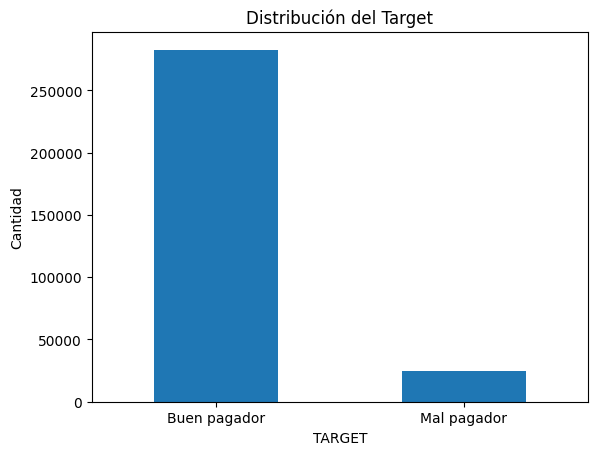

In [4]:
# Distribución del target
target_counts = df_raw['TARGET'].value_counts()
porcentaje_impago = df_raw['TARGET'].mean() * 100

print(f"Tasa de impago: {porcentaje_impago:.2f}%")
target_counts.plot(kind='bar')
plt.title('Distribución del Target')
plt.xticks([0, 1], ['Buen pagador', 'Mal pagador'], rotation=0)
plt.ylabel('Cantidad')
plt.show()

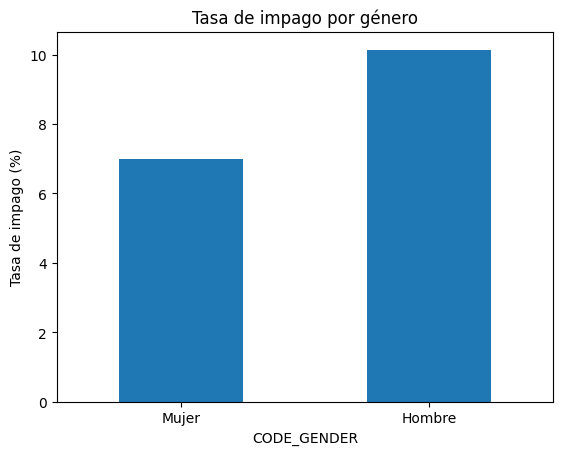

In [5]:
# Tasa de impago por género
impago_genero = df_raw[df_raw['CODE_GENDER'].isin(['M', 'F'])].groupby('CODE_GENDER')['TARGET'].mean() * 100

impago_genero.plot(kind='bar')
plt.title('Tasa de impago por género')
plt.xticks([0, 1], ['Mujer', 'Hombre'], rotation=0)
plt.ylabel('Tasa de impago (%)')
plt.show()

### Conclusiones del EDA
- El dataset está muy desbalanceado: solo el 8% son malos pagadores.
Se deberá compensar durante el entrenamiento dando más peso a la clase positiva.
- EXT_SOURCE_1 tiene un 56% de nulos y EXT_SOURCE_3 un 20%.
Se imputan con la mediana y se añade un flag por columna para que la red sepa dónde faltaba información.
- Existe una diferencia real en la tasa de impago por género (hombres ~10% vs mujeres ~7%),
lo que justifica la necesidad de una FAIR loss para evitar discriminación.

## 4. Arquitectura customizada: Ratio de Endeudamiento

La capa `RatioEndeudamientoLayer` (definida en `src/base.py`) calcula internamente
una señal de **carga de endeudamiento** combinando variables financieras de entrada
(`AMT_CREDIT`, `AMT_ANNUITY`, `AMT_INCOME_TOTAL`) y le aplica una **saturación
`tanh`** (restricción matemática que acota la señal a `(-1, 1)`) antes de
concatenarla al vector de features. Es una transformación determinista (sin
parámetros entrenables): una restricción "física" sobre el problema.

In [6]:
# Demostración: la capa añade 1 feature (la señal de endeudamiento saturada)
capa = RatioEndeudamientoLayer()
demo = capa(keras.ops.convert_to_tensor(X_train[:3], dtype="float32"))
print("Entrada:", X_train[:3].shape, "-> Salida de la capa:", tuple(demo.shape))

Entrada: (3, 11) -> Salida de la capa: (3, 12)


## 5. Modelo Base

Arquitectura (en `src.base.build_model`): `Input → RatioEndeudamientoLayer →
Dense(64, relu) → Dropout → Dense(32, relu) → Dropout → Dense(1, sigmoid)`. Se
entrena con **BCE** y `class_weight` balanceado. Esta es exactamente la misma
arquitectura sobre la que `02_fair_loss.ipynb` aplica la FAIR loss.

In [7]:
model = build_model(X_train.shape[1])
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc")],
)
model.summary()

Model: "credit_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ratio_endeudamiento             │ (None, 12)             │             0 │
│ (RatioEndeudamientoLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pd (Dense)                      │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
cw = compute_class_weight_balanced(y_train)
es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train, np.asarray(y_train).astype("float32"),
    validation_split=0.15,
    epochs=40, batch_size=512, class_weight=cw,
    verbose=2, callbacks=[es],
)

Epoch 1/40


409/409 - 5s - 11ms/step - auc: 0.7141 - loss: 0.6221 - val_auc: 0.7369 - val_loss: 0.6111


Epoch 2/40


409/409 - 2s - 4ms/step - auc: 0.7263 - loss: 0.6113 - val_auc: 0.7385 - val_loss: 0.6063


Epoch 3/40


...

409/409 - 2s - 4ms/step - auc: 0.7369 - loss: 0.6026 - val_auc: 0.7422 - val_loss: 0.6024


Epoch 16/40


409/409 - 2s - 4ms/step - auc: 0.7365 - loss: 0.6032 - val_auc: 0.7422 - val_loss: 0.5999


Epoch 17/40


409/409 - 2s - 4ms/step - auc: 0.7367 - loss: 0.6029 - val_auc: 0.7425 - val_loss: 0.6007


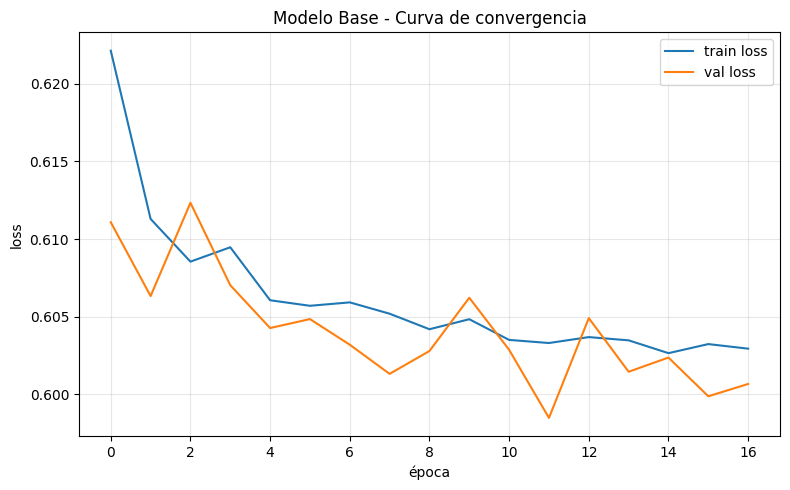

In [9]:
# Curva de loss (convergencia) -> results/loss_curve_base.png
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Modelo Base - Curva de convergencia")
plt.xlabel("época"); plt.ylabel("loss"); plt.grid(alpha=0.3); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "loss_curve_base.png"), dpi=130)
plt.show()

In [10]:
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

p_test = model.predict(X_test, verbose=0, batch_size=4096).ravel()
print(f"Accuracy: {accuracy_score(y_test, (p_test >= 0.5).astype(int)):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, p_test):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, p_test):.4f}")

Accuracy: 0.6857
ROC-AUC:  0.7409
PR-AUC:   0.2207
